In [33]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
import torch

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
pp = Preprocessor()

In [35]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [36]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 2000).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818
Genes before Treshold: 2003
count    2003.000000
mean       76.306041
std       158.918820
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max       519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [37]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

Genes before Treshold: 1805
count    1805.000000
mean       30.929640
std        84.082264
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805
Samples: 519, Genes: 1806


In [38]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.879097,10.704586,10.782180,10.716942,10.726453,69262.336815,0.000000e+00,0.000000e+00
CCR7,6.044679,5.968886,6.192913,6.938782,6.166055,1634.501163,0.000000e+00,0.000000e+00
FBXO48,5.023124,4.763917,4.780206,4.962661,4.810496,6907.552264,0.000000e+00,0.000000e+00
PTPRN2,6.436115,7.635121,7.006290,5.565086,7.144821,1749.138908,0.000000e+00,0.000000e+00
TRIOBP,10.290598,10.180434,10.190821,10.256202,10.199346,42629.167766,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
SSX4,0.762482,0.202256,0.332518,0.421870,0.283380,15.974664,4.389646e-13,4.399411e-13
RPTN,0.281796,0.270517,0.264407,0.518887,0.310740,15.355910,1.456288e-12,1.458717e-12
REXO1L1P,0.128429,0.201275,0.248773,0.140834,0.195561,15.321054,1.557997e-12,1.559728e-12
CSN1S1,0.152372,0.442308,0.377112,0.388976,0.410550,14.655928,5.644621e-12,5.647756e-12


In [60]:
N_GENES = 500
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES]
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, N_GENES)
Torch_preprocessing.genes_expression = top_genes_limma

In [61]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, N_GENES)
Torch_preprocessing.genes_expression = top_genes_limma
X_scaled, durations, events, scaler = Torch_preprocessing.get_data_set(120)

Genes before Treshold: 503
count    503.000000
mean       1.075547
std        3.783253
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       38.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 503


In [62]:
X_scaled.shape

(519, 500)

In [63]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [64]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

In [65]:
train_X.shape

torch.Size([415, 500])

In [66]:
in_features = train_X.shape[1]
num_nodes = [32, 16]
out_features = 1
batch_norm = True
dropout = 0.3
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

In [67]:
model = CoxPH(net, tt.torchtuples.optim.Adam)


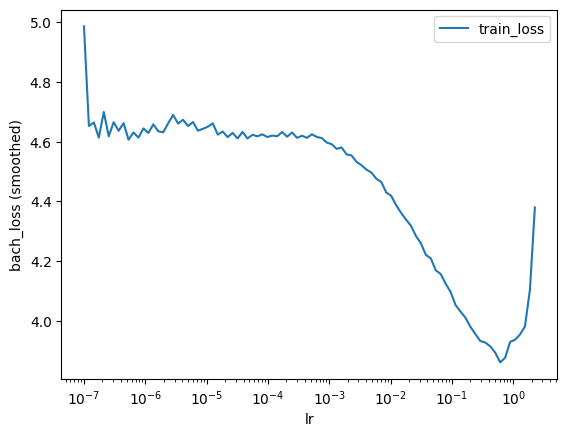

In [68]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=10)

_ = lrfinder.plot()

In [69]:
train_durations.shape

torch.Size([415])

In [70]:
learning_rate = lrfinder.get_best_lr()
learning_rate

0.0613590727341321

In [71]:
model.optimizer.set_lr(0.01)


In [72]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [73]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.5731,	val_loss: 1.9173
1:	[0s / 0s],		train_loss: 4.3704,	val_loss: 1.9384
2:	[0s / 0s],		train_loss: 3.9644,	val_loss: 1.8817
3:	[0s / 0s],		train_loss: 3.7659,	val_loss: 1.9019
4:	[0s / 0s],		train_loss: 3.7747,	val_loss: 2.0330
5:	[0s / 0s],		train_loss: 3.5371,	val_loss: 2.2282
6:	[0s / 0s],		train_loss: 3.3449,	val_loss: 2.4164
7:	[0s / 0s],		train_loss: 3.5024,	val_loss: 2.5683
8:	[0s / 0s],		train_loss: 3.3014,	val_loss: 2.5749
9:	[0s / 0s],		train_loss: 3.0394,	val_loss: 2.4834
10:	[0s / 0s],		train_loss: 2.8399,	val_loss: 2.3759
11:	[0s / 0s],		train_loss: 3.0940,	val_loss: 2.3538
12:	[0s / 0s],		train_loss: 2.8990,	val_loss: 2.3819
CPU times: total: 281 ms
Wall time: 200 ms


torch.Size([52, 500])

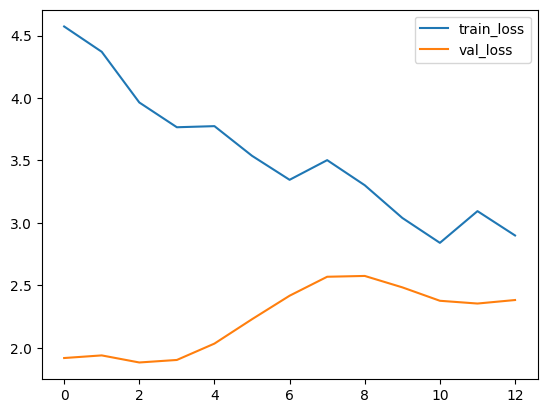

In [74]:
_ = log.plot()
val_X.shape

In [75]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()
val_durations.shape

torch.Size([52])

In [76]:
_ = model.compute_baseline_hazards()

In [77]:
surv = model.predict_surv_df(input=test_X)
surv.shape

(342, 52)

In [78]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(342, 52)

In [79]:
risk_nn = model.net(test_X).flatten()

list_risk = []
for i in risk_nn:
    list_risk.append(i.item())



For this group the risk High

For the time 0 the risk group is 25
For the time 12 the risk group is 23
For the time 24 the risk group is 12
For the time 36 the risk group is 7
For the time 48 the risk group is 5
For the time 60 the risk group is 2
For the time 72 the risk group is 1
For the time 84 the risk group is 1
For the time 96 the risk group is 1
For the time 108 the risk group is 0
For the time 120 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 23
For the time 24 the risk group is 13
For the time 36 the risk group is 9
For the time 48 the risk group is 6
For the time 60 the risk group is 6
For the time 72 the risk group is 5
For the time 84 the risk group is 5
For the time 96 the risk group is 3
For the time 108 the risk group is 1
For the time 120 the risk group is 0


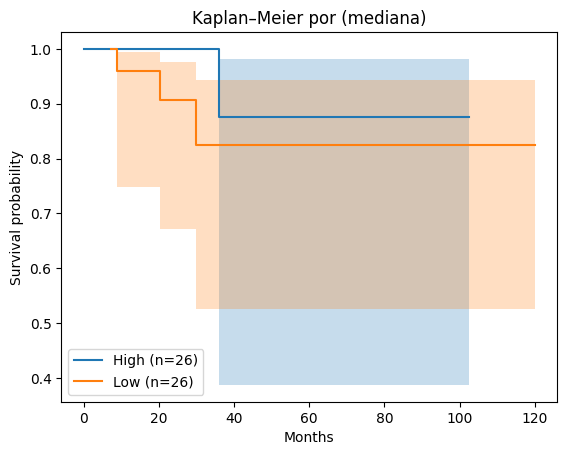

In [80]:
df = pd.DataFrame()

thr = np.median(list_risk)
df["group"] = np.where(risk_nn > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

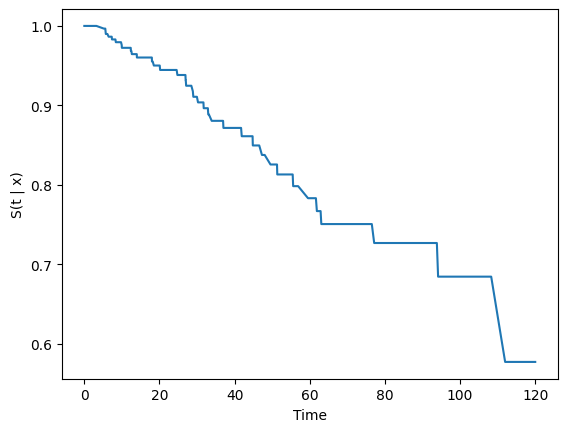

In [81]:
surv.iloc[:, 50].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel("Time")

In [82]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [83]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


In [84]:
print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.5470085470085471


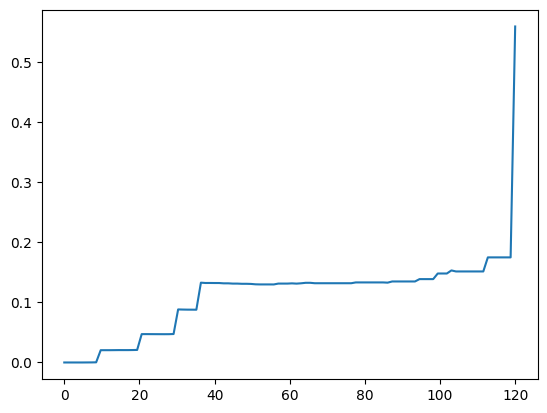

In [340]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [341]:
ev.integrated_brier_score(time_grid=time_grid)

0.1098432854907236

In [342]:
ev.integrated_nbll(time_grid)

risk_nn = model.net(test_X).flatten()

risk_nn.shape

risk_nn

tensor([ 0.0515, -0.6031, -0.8806, -0.9765, -0.3064,  0.0041,  0.0221, -0.0504,
        -0.2115, -0.3976,  0.4855,  0.0409,  0.1196, -0.4282, -0.5229,  0.3057,
        -0.5135, -0.2103, -0.0454,  0.5262,  0.0455, -0.1728, -0.1965,  1.0415,
         0.2440, -0.3222,  0.3048, -0.4173,  0.6878,  0.4610,  0.2450, -0.5209,
        -0.2368,  0.4121, -0.1274,  0.3026,  0.8990, -0.1600,  0.3501,  0.7929,
        -0.3158,  0.1909,  0.1872,  0.4394, -0.3642, -0.3289,  0.4967,  0.3030,
         0.1632,  0.3558,  0.5769, -0.0256], grad_fn=<ViewBackward0>)